<a href="https://colab.research.google.com/github/LuanaGoncalves177/Linguagem_Python_Colab/blob/main/Python_Visualiza%C3%A7%C3%A3o_%26_Dashboars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import statistics as sts

# 1. Importação do data base "sujo"

dataset = pd.read_csv("dados.csv", sep=';')
dataset.head()

,CODIGO,MUNICIPIO,PIB,VALOREMPENHO
0,106,SANTANA DO LIVRAMENTO,12240.76,1088666.10
1,113,SANTO ANGELO,16575.82,800669.92
2,118,SAO FRANCISCO DE ASSIS,12037.61,466122.80
3,13,CACAPAVA DO SUL,13674.54,485535.86
4,120,SAO GABRIEL,19912.38,533719.86


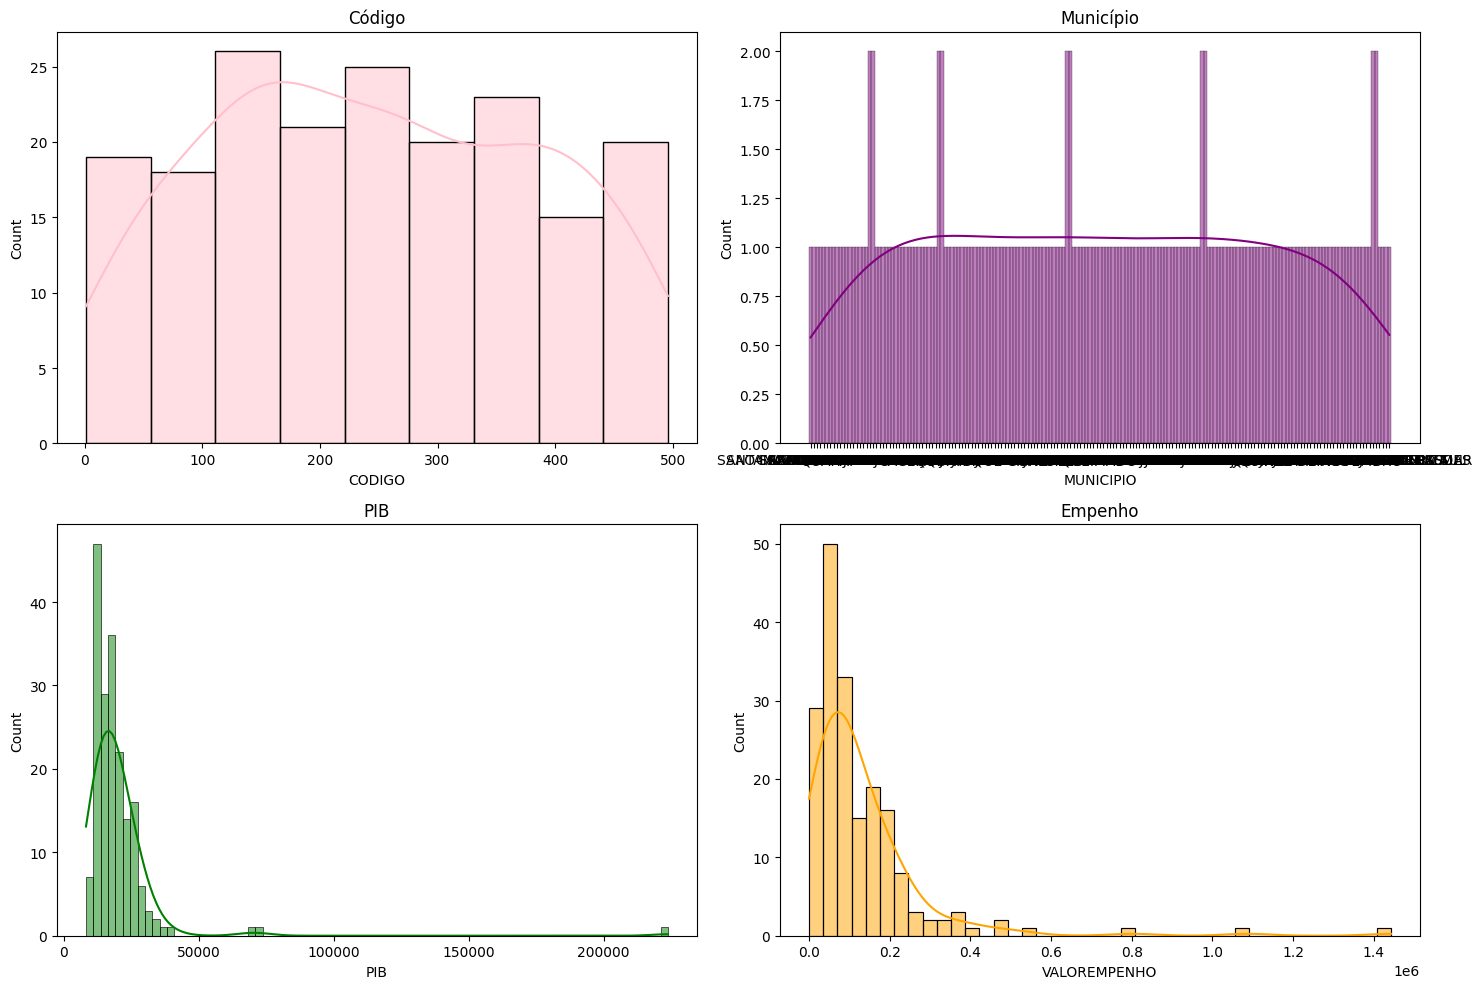

In [ ]:
import seaborn as srn
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.subplot(2,2,1)
srn.histplot(dataset['CODIGO'], kde=True, color='pink').set(title="Código")
plt.subplot(2,2,2)
srn.histplot(dataset['MUNICIPIO'], kde=True, color='purple').set(title="Município")
plt.subplot(2,2,3)
srn.histplot(dataset['PIB'], kde=True, color='green').set(title="PIB")
plt.subplot(2,2,4)
srn.histplot(dataset['VALOREMPENHO'], kde=True, color='orange').set(title="Empenho")
plt.tight_layout()
plt.show()

In [ ]:
#2. Análise Exploratória

#2.1. Remover duplicatas da coluna código

# 1.1. Mostrar os itens duplicados
dataset[dataset.duplicated(subset=['CODIGO'], keep=False)]
print(len(dataset))

187


In [ ]:
# 1.2.Remover as duplicatas e atualizar o dataset
dataset.drop_duplicates(subset=['CODIGO'], keep='first', inplace=True)

# 1.3. Mostrar as colunas após a remoção das duplicatas
print(len(dataset))

172


In [ ]:
#2.2. Resolução dos outliers na coluna do PIB

# 1. Cáculo da median
mediana_pib = dataset['PIB'].median()
print("Mediana")
mediana_pib

Mediana


16846.77

In [ ]:
#2. Mostrar os outliers

fig = px.box(dataset, x='PIB')
fig.show()

In [ ]:
#3. Cálculo do desvio padrão
desv = sts.stdev(dataset['PIB'])
print("Desvio padrão")
desv

Desvio padrão


17650.23526703751

In [ ]:
#4. Substiruição dos outliers
dataset.loc[dataset['PIB'] >= 4*desv]
mmediana = sts.median(dataset['PIB'])

#5. Conferirência
dataset.loc[dataset['PIB'] >= 4*desv, 'PIB'] = mmediana
dataset.loc[dataset['PIB'] >= 4*desv]

,CODIGO,MUNICIPIO,PIB,VALOREMPENHO


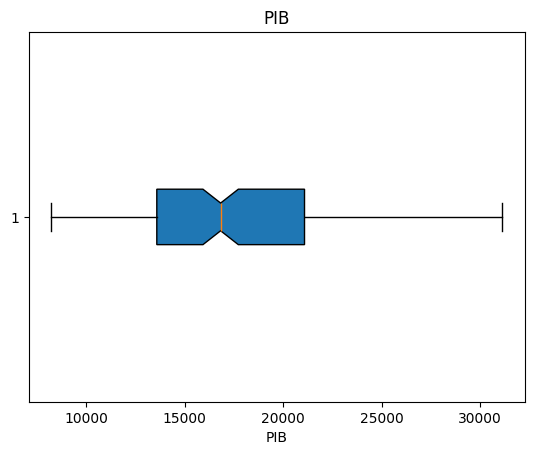

In [ ]:
#6. Mostrar a correção dos outliers
import matplotlib.pyplot as plt

#Boxplot da base
plt.boxplot(dataset['PIB'], vert=False, showfliers= False, notch = True, patch_artist=True)
plt.title("PIB")
plt.xlabel("PIB")
plt.show()

In [ ]:
dataset.shape

(172, 4)

In [ ]:
#2.3. Resolução dos outliers na coluna Valor de Empenho

# 1. Cáculo da mediana
mediana_emp = dataset['VALOREMPENHO'].median()
print("Mediana")
mediana_emp

Mediana


83477.15

In [ ]:
    #2. Mostrar os outliers

import matplotlib.pyplot as plt

#Boxplot da base

fig = px.box(dataset, x='VALOREMPENHO')
fig.show()

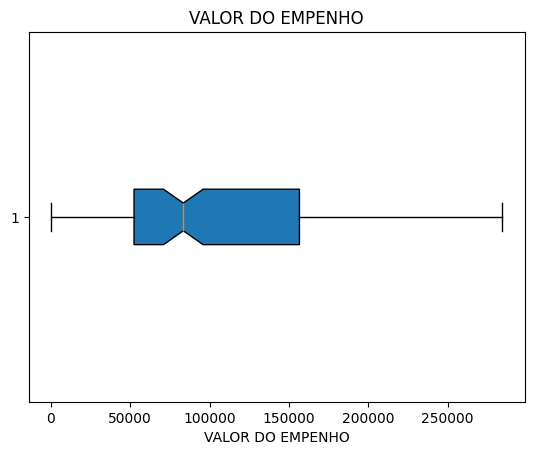

In [ ]:
import matplotlib.pyplot as plt

#Boxplot da base
plt.boxplot(dataset['VALOREMPENHO'], vert=False, showfliers= False, notch = True, patch_artist=True)
plt.title("VALOR DO EMPENHO")
plt.xlabel("VALOR DO EMPENHO")
plt.show()

In [ ]:
#3. Cálculo do desvio padrão
desv = sts.stdev(dataset['VALOREMPENHO'])
print("Desvio padrão")
desv

Desvio padrão


166939.00802593995

In [ ]:
#4. Substiruição dos outliers
dataset.loc[dataset['VALOREMPENHO'] >= 6*desv]
mmediana = sts.median(dataset['VALOREMPENHO'])

#5. Conferirênca
dataset.loc[dataset['VALOREMPENHO'] >= 6*desv,'VALOREMPENHO'] = mmediana
dataset.loc[dataset['VALOREMPENHO'] >= 6*desv]
#X = 3*desv
#print(X)


,CODIGO,MUNICIPIO,PIB,VALOREMPENHO


In [ ]:
import plotly.express as px

print('Gráfico de Dispersão PIB vs, Valor de Empenho de 2018')
# Criando o gráfico de dispersão
fig = px.scatter(dataset,
                 x="PIB",
                 y="VALOREMPENHO",
                 hover_name="MUNICIPIO",  # Mostra o nome da cidade ao passar o mouse
                 title="Correlação: PIB vs. Valor de Empenho",
                 labels={"PIB": "PIB Municipal", "VALOREMPENHO": "Valor Empenhado"},
                 trendline="ols") # Opcional: adiciona uma linha de tendência

fig.show()

Gráfico de Dispersão PIB vs, Valor de Empenho de 2018


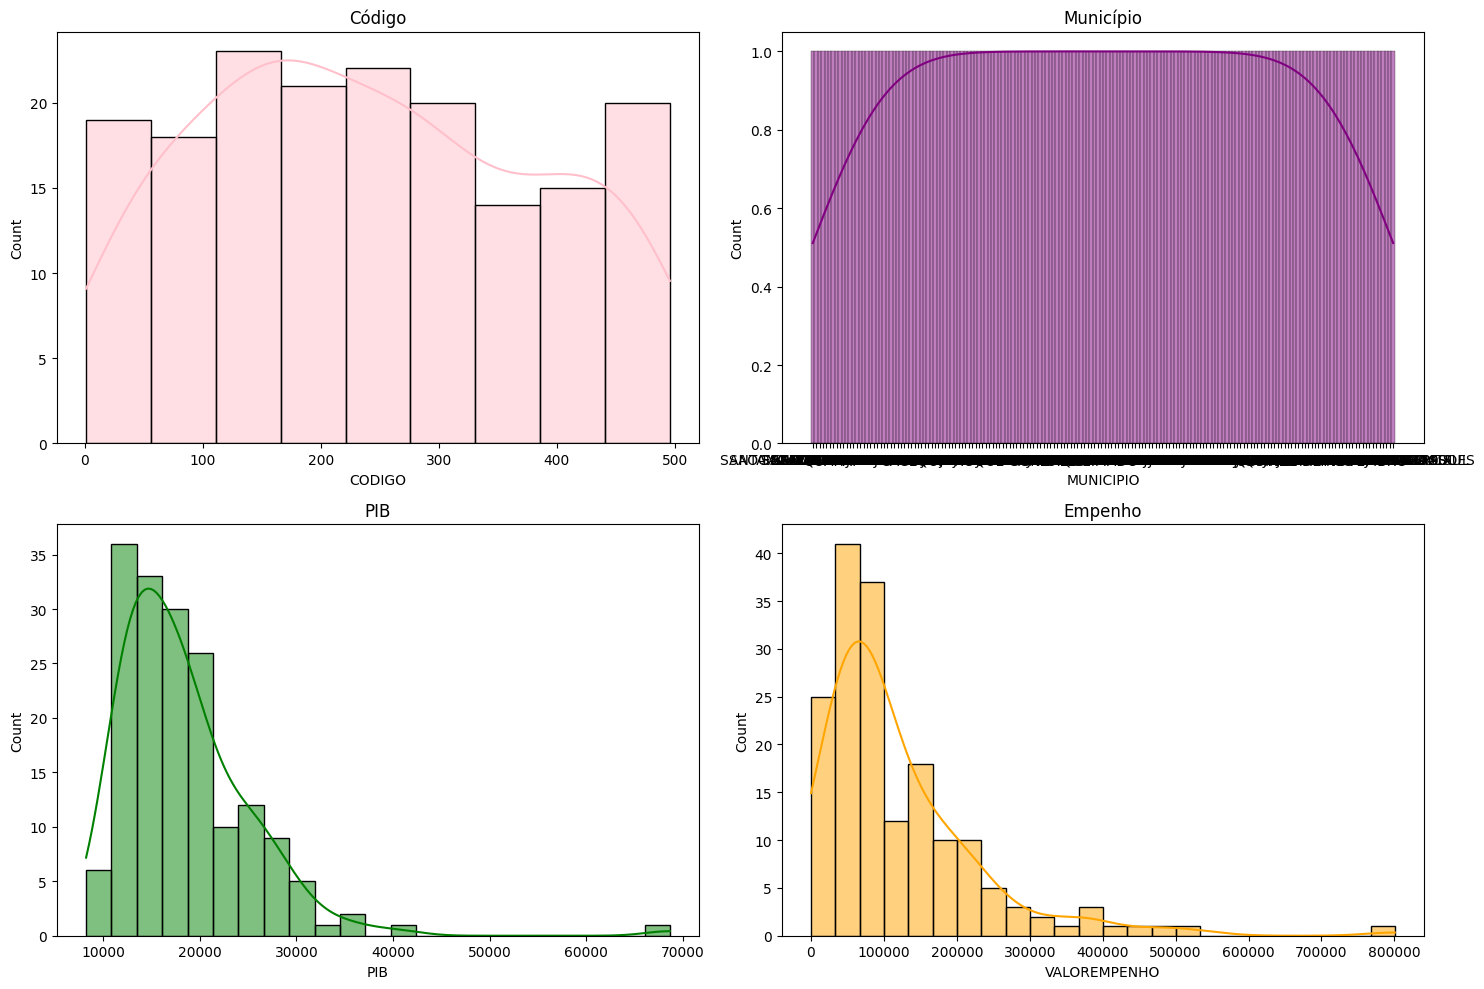

In [ ]:
import seaborn as srn
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.subplot(2,2,1)
srn.histplot(dataset['CODIGO'], kde=True, color='pink').set(title="Código")
plt.subplot(2,2,2)
srn.histplot(dataset['MUNICIPIO'], kde=True, color='purple').set(title="Município")
plt.subplot(2,2,3)
srn.histplot(dataset['PIB'], kde=True, color='green').set(title="PIB")
plt.subplot(2,2,4)
srn.histplot(dataset['VALOREMPENHO'], kde=True, color='orange').set(title="Empenho")
plt.tight_layout()
plt.show()